已连接到 spacegame (Python 3.12.2)

In [ ]:
import sys
project_root = '/nas1/huyulun2021/codes/spacegame-2025/psro-ppo-project'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.special import softmax
from src.utils.meta_solver import fictitious_play,  uniform_sample, naive_sp, LP_nash
from src.utils.payoff_table import PayoffTable
import matplotlib.pyplot as plt

def compute_best_response_pure(payoff_matrix, opponent_strategy):
    """
    计算对给定对手策略的纯策略最佳响应
    
    Args:
        payoff_matrix: 收益矩阵 (行玩家视角)
        opponent_strategy: 对手的混合策略分布
    
    Returns:
        best_response_idx: 最佳响应策略的索引
        best_response_value: 最佳响应的期望收益
    """
    # 计算每个纯策略对抗对手混合策略的期望收益
    expected_payoffs = payoff_matrix @ opponent_strategy
    
    # 找到最佳响应
    best_response_idx = np.argmax(expected_payoffs)
    best_response_value = expected_payoffs[best_response_idx]
    
    return best_response_idx, best_response_value

def compute_exploitability_single_strategy(payoff_matrix, strategy_idx):
    """
    计算单个纯策略的可利用性
    """
    # 创建纯策略分布 (只有一个策略概率为1)
    strategy_dist = np.zeros(len(payoff_matrix))
    strategy_dist[strategy_idx] = 1.0
    
    # 计算最佳响应
    br_idx, br_value = compute_best_response_pure(payoff_matrix, strategy_dist)
    
    # 该策略自对弈的收益
    self_play_value = payoff_matrix[strategy_idx, strategy_idx]
    
    # 可利用性 = 最佳响应收益 - 自对弈收益
    exploitability = br_value - self_play_value
    
    return exploitability, br_idx, br_value, self_play_value

def compute_exploitability_mixed_strategy(payoff_matrix, mixed_strategy):
    """
    计算混合策略的可利用性
    """
    # 计算最佳响应
    br_idx, br_value = compute_best_response_pure(payoff_matrix, mixed_strategy)
    
    # 混合策略自对弈的期望收益
    # E[u(μ, μ)] = Σᵢ Σⱼ μᵢ * μⱼ * u(i,j)
    self_play_value = mixed_strategy.T @ payoff_matrix @ mixed_strategy
    
    # 可利用性
    exploitability = br_value - self_play_value
    
    return exploitability, br_idx, br_value, self_play_value


def solve_nash_equilibrium_2player_zerosum(payoff_table):
    """
    使用线性规划求解零和博弈的纳什均衡
    行玩家希望最大化他的最低收益，列玩家希望最小化行玩家的收益
    
    参数:
        payoff_table: 行玩家收益矩阵
        
    返回:
        nash_weights: 纳什均衡策略
    """
    # assert is_zero_sum_game(payoff_table.table), "Payoff table is not zero-sum game"
    payoff_matrix = payoff_table
    # Get dimensions
    num_rows, num_cols = payoff_matrix.shape
    
    c = np.zeros(num_rows + 1)
    c[-1] = -1  # maximize v ⟺ minimize -v
    
    # Constraints:
    # 1. For each column j: sum_i (x_i * A_ij) >= v
    #    This ensures v is the minimum payoff across all columns
    A_ub = np.zeros((num_cols, num_rows + 1))
    for j in range(num_cols):
        A_ub[j, :num_rows] = -payoff_matrix[:, j]  # Negative because we want >=
        A_ub[j, -1] = 1
    b_ub = np.zeros(num_cols)
    
    # 2. Sum of probabilities equals 1
    A_eq = np.zeros((1, num_rows + 1))
    A_eq[0, :num_rows] = 1
    A_eq[0, -1] = 0  # v is not part of the probability distribution
    b_eq = np.array([1.0])
    
    # 3. Probabilities are non-negative
    bounds = [(0, None) for _ in range(num_rows)] + [(None, None)]  # x_i >= 0, v free
    
    # Solve LP
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, 
                  bounds=bounds, method='highs',)
    
    if not res.success:
        raise ValueError(f"Linear programming failed: {res.message}")
    
    # Extract results
    row_strategy = res.x[:num_rows]
    value = res.x[-1]

    c = np.zeros(num_cols + 1)
    c[-1] = 1  # minimize u
    
    # Constraints:
    # 1. For each row i: sum_j (y_j * A_ij) <= u
    #    This ensures u is the maximum loss across all rows
    A_ub = np.zeros((num_rows, num_cols + 1))
    for i in range(num_rows):
        A_ub[i, :num_cols] = payoff_matrix[i, :]
        A_ub[i, -1] = -1  # Negative because we want <=
    b_ub = np.zeros(num_rows)
    
    # 2. Sum of probabilities equals 1
    A_eq = np.zeros((1, num_cols + 1))
    A_eq[0, :num_cols] = 1
    A_eq[0, -1] = 0  # u is not part of the probability distribution
    b_eq = np.array([1.0])
    
    # 3. Probabilities are non-negative
    bounds = [(0, None) for _ in range(num_cols)] + [(None, None)]  # y_j >= 0, u free
    
    # Solve LP
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, 
                  bounds=bounds, method='highs', )
    
    if not res.success:
        raise ValueError(f"Linear programming failed: {res.message}")
    
    # Extract results
    col_strategy = res.x[:num_cols]
    col_value = res.x[-1]
    
    # Sanity check: the values from both LPs should be equal
    if not np.isclose(value, col_value):
        print(f"Warning: Game values don't match exactly: {value} vs {col_value}")
    
    return row_strategy, value

def simulate_psro_exploitability(payoff_matrix, strategies_sequence, meta_solver=LP_nash,
                                 **solver_config):
    """
    模拟PSRO过程中策略池的可利用性变化
    strategies_sequence: 策略加入的顺序 (策略索引列表)
    """
    exploitability_history = []
    
    for step, new_strategy_idx in enumerate(strategies_sequence):
        # 当前策略池 (包含到目前为止的所有策略)
        current_pool = strategies_sequence[:step+1]
        
        # 简单的均匀分布元策略
        pool_size = len(current_pool)
        uniform_weights = np.ones(pool_size) / pool_size
        
        # # 构建当前策略池的均匀策略
        # mixed_strategy = np.zeros(len(payoff_matrix))
        # for i, strategy_idx in enumerate(current_pool):
        #     mixed_strategy[strategy_idx] = uniform_weights[i]

        # 构建当前策略池的NE策略
        mixed_strategy = np.zeros(len(payoff_matrix))
        sub_matrix = payoff_matrix[:pool_size,:pool_size]
        sub_ne_strategy, _, _ = meta_solver(PayoffTable(sub_matrix),**solver_config)
        for i, strategy_idx in enumerate(current_pool):
            mixed_strategy[strategy_idx] = sub_ne_strategy[i]
        
        # 计算可利用性
        exploit, _, _, _ = compute_exploitability_mixed_strategy(payoff_matrix, mixed_strategy)
        exploitability_history.append(exploit)
        
        print(f"迭代 {step+1:2d}: 加入策略{new_strategy_idx}, "
              f"策略池大小: {pool_size}, Exploitability: {exploit:.3f}")
    
    return exploitability_history

def dpp_trace(M):
    L = M @ M.T
    I = np.eye(L.shape[0])
    return np.linalg.slogdet(I + L)[1]

def simulate_dpp(M, indices):
    traces = []
    for i in range (indices[0], indices[1]):
        sub_M = M[indices[0]:i+1,:]
        trace = dpp_trace(sub_M)
        traces.append(trace)
    return traces

def get_submatrix(full_matrix, indices):
    """
    从完整矩阵中提取子矩阵。

    """
    return full_matrix[np.ix_(indices, indices)]

In [ ]:

strat_num=50
M_all = np.load("../results/metrics/20260401_div2/payoff_final.npy")
M1 = get_submatrix(M_all, list(range(0*strat_num, (0+1)*strat_num)))

M2 = get_submatrix(M_all, list(range(1*strat_num, (1+1)*strat_num)))

M3 = get_submatrix(M_all, list(range(2*strat_num, (2+1)*strat_num)))

M4 = get_submatrix(M_all, list(range(3*strat_num, (3+1)*strat_num)))

indices1 = (0,50)
traces1 = np.array(simulate_dpp(M_all, indices1))
indices2 = (50,100)
traces2 = np.array(simulate_dpp(M_all, indices2))
indices3 = (100,150)
traces3 = np.array(simulate_dpp(M_all, indices3))
indices4 = (150,200)
traces4 = np.array(simulate_dpp(M_all, indices4))

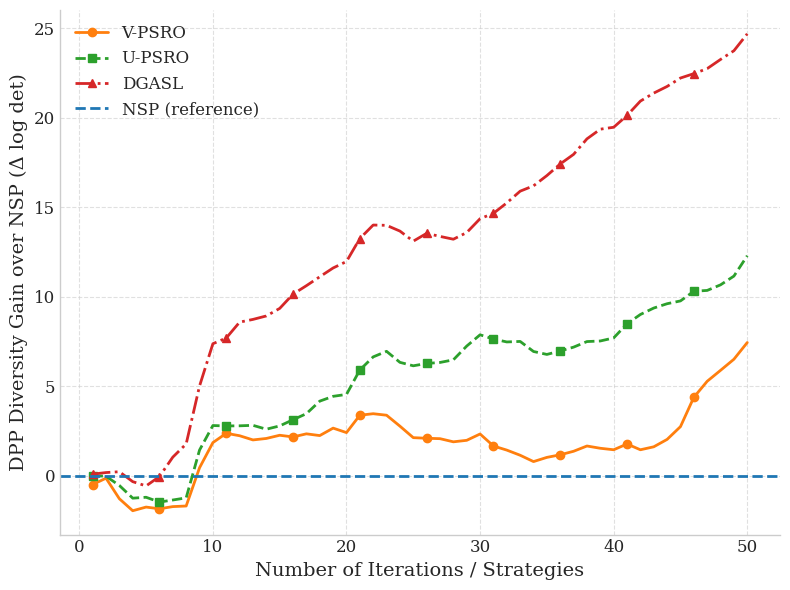

In [ ]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
# 设置字号大小
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 2.0


fig, ax = plt.subplots(figsize=(8,6)) # 标准的 4:3 比例
    
# 推荐使用色盲友好的调色板，或者 Seaborn 的 deep 调色板
# 下面这是一套常用的高对比度学术配色方案
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
# 不同的线型和标记，保证黑白打印也能区分
line_styles = ['-', '--', '-.', ':', '-', '--']
markers = ['o', 's', '^', 'D', 'v', 'p']

x = np.arange(1, 51)

baseline = np.array(traces1)  # NSP 作为客观基准

# 只画其他三条相对于 NSP 的差值
for i, (traces, label) in enumerate(zip(
    [traces2, traces3, traces4],
    ["V-PSRO", "U-PSRO", "SPADE-PSRO"]
)):
    diff = np.array(traces) - baseline

    ax.plot(x, diff, 
        label=label, 
        color=colors[i % len(colors)+1], 
        linestyle=line_styles[i % len(line_styles)],
        marker=markers[i % len(markers)],
        markevery=max(1, len(x)//10), # 均匀分布 10 个标记
        markersize=6)

# ==========================================
# 4. 图表美化 (Labels, Grids, Spines)
# ==========================================
ax.set_xlabel('Number of Iterations / Strategies')
# Y轴最好加上对数刻度(Log Scale)，因为 Exploitability 往往是指数下降的
ax.set_ylabel('DPP Diversity Gain over NSP (Δ log det)') 
# ax.set_yscale('log') # 【可选】如果你的 Exploitability 跨度很大，强烈建议开启
ax.axhline(y=0, color=colors[0], linestyle="--", linewidth=2, label="NSP (reference)")

# 去除上方和右方的边框线，让图表看起来更干净（学术图标配）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加轻微的网格线辅助阅读
ax.grid(True, linestyle='--', alpha=0.6)

# 图例设置：去边框，放在不遮挡数据的地方
ax.legend(frameon=False, loc='best')

ax.legend(frameon=False, loc='best')

plt.tight_layout() # 自动调整边缘空白
    
plt.savefig("../tests/output/dpp_relative.pdf", dpi=300,bbox_inches='tight')
plt.show()

In [ ]:

winmap = np.load('../results/metrics/crossplay_win_meta_20260403div2/win.npy')
heatmap = np.load('../results/metrics/crossplay_win_meta_20260403div2/payoff.npy')

In [ ]:

winrandom = np.load('../results/metrics/crossplay_win_meta_20260403div2/random/win.npy')
heatrandom = np.load('../results/metrics/crossplay_win_meta_20260403div2/random/payoff.npy')

In [ ]:
winrandom=winrandom[:,0]

In [ ]:
# winmap: (7,7)
# winrandom: (7,) 或 (1,7)

winrandom = winrandom.reshape(7,)  # 保证是 1×7

# 横向拼接
M = np.hstack([winmap, winrandom.reshape(7,1)])

# 纵向拼接
M = np.vstack([M, np.append(1000-winrandom, 0)])

# M 就是最终的 8×8 对称矩阵
heatrandom = heatrandom.reshape(7,)  # 保证是 1×7

# 横向拼接
H = np.hstack([heatmap, heatrandom.reshape(7,1)])

# 纵向拼接
H = np.vstack([H, -np.append(heatrandom, 0)])


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

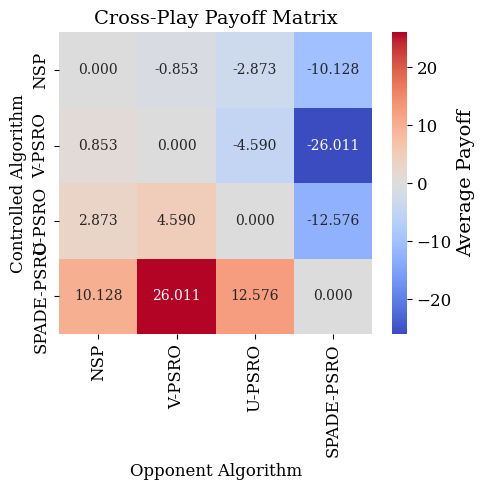

In [ ]:
plt.figure(figsize=(5, 5))

algorithms = ["NSP", "V-PSRO", "U-PSRO","SPADE-PSRO",]#"ddpg","td3","lstm-ppo","random"]
sns.heatmap(H[:4,:4]/500, annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=algorithms, yticklabels=algorithms, 
            cbar_kws={'label': 'Average Payoff'})
plt.title("Cross-Play Payoff Matrix", fontsize=14)
plt.xlabel("Opponent Algorithm", fontsize=12)
plt.ylabel("Controlled Algorithm", fontsize=12)
plt.tight_layout()
plt.savefig("../tests/output/crossplay_payoff.pdf", dpi=300)
plt.show()


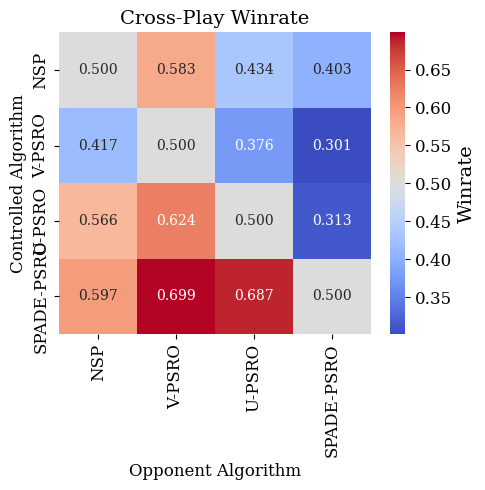

In [ ]:
M = M/1000
M += np.eye(len(M))/2
plt.figure(figsize=(5, 5))
algorithms = ["NSP", "V-PSRO", "U-PSRO","SPADE-PSRO"]#,"ddpg","td3","lstm-ppo","random"]
sns.heatmap(M[:4,:4], annot=True, fmt=".3f", cmap="coolwarm",
            xticklabels=algorithms, yticklabels=algorithms, 
            cbar_kws={'label': 'Winrate'})
plt.title("Cross-Play Winrate", fontsize=14)
plt.xlabel("Opponent Algorithm", fontsize=12)
plt.ylabel("Controlled Algorithm", fontsize=12)
plt.tight_layout()
plt.savefig("../tests/output/crossplay_winrate.pdf", dpi=300)
plt.show()


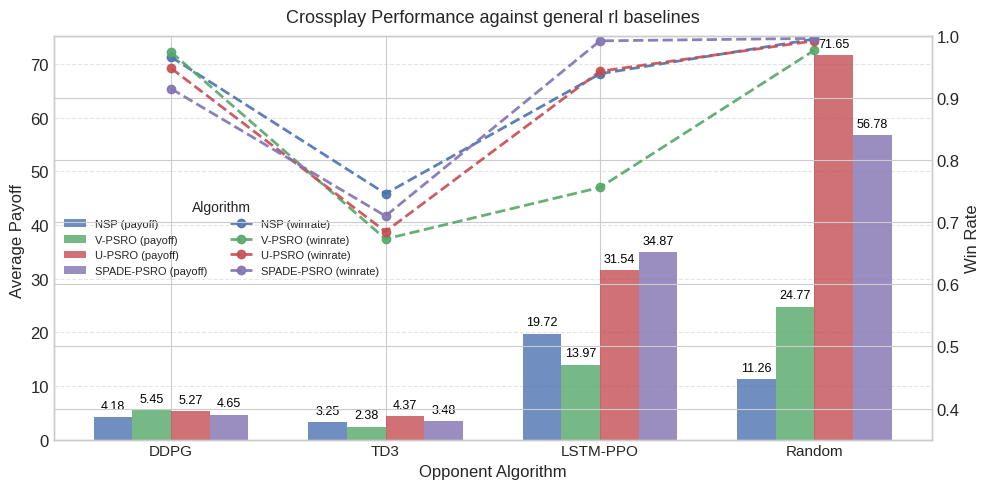

In [ ]:
pa_win = M[:4,4:]
pa_pay = H[:4,4:]/1000
labels = ["DDPG", "TD3", "LSTM-PPO", "Random"]


# ==== 示例数据（请替换成你自己的实际值）====
algos = ["NSP", "V-PSRO", "U-PSRO", "SPADE-PSRO"]
opponents = ["DDPG", "TD3", "LSTM-PPO", "Random"]

# ==== 绘图 ====
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

bar_width = 0.18
x = np.arange(len(opponents))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

# 左轴绘制 payoff 柱状图
for i, algo in enumerate(algos):
    offset = (i - 1.5) * bar_width
    bars = ax1.bar(x + offset, pa_pay[i], width=bar_width,
            label=f"{algo} (payoff)", color=colors[i], alpha=0.8)
    
        # 在条形上方标出winrate
    for j, b in enumerate(bars):
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                # f"{pa_win[i, j]*100:.1f}%",
                f"{pa_pay[i, j]:.2f}",
                ha='center', va='bottom', fontsize=9, color='black')
        

        

ax1.set_ylabel("Average Payoff ", fontsize=12)
ax1.set_xlabel("Opponent Algorithm", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(opponents, fontsize=11)

# 创建右轴用于 Winrate
ax2 = ax1.twinx()

# 绘制 Winrate 折线
for i, algo in enumerate(algos):
    ax2.plot(x, pa_win[i], color=colors[i], linestyle='--', marker='o',
             label=f"{algo} (winrate)", alpha=0.9)

ax2.set_ylabel("Win Rate", fontsize=12)
ax2.set_ylim(0.35, 1)

# === 图例与样式 ===
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, fontsize=8, ncol=2, loc="center left", title="Algorithm")

ax1.set_title("Crossplay Performance against general rl baselines", fontsize=13, pad=10)
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../tests/output/baselines.pdf", dpi=300)
plt.show()
